# The importance of neutral baselines: Cross-structural priming ≠ Shared representation

#### Grusha Prasad, Aniello De Santo, Shota Momma  (HSP 2026)

## Steps for simulation:

Partial target: "The cat examined"

After "The cat", there are four possible parse states: RRC-compatible, FRC-compatible, ProgRRC-compatible, AMV-compatible. 

At examined, there are two categories: AMV-category or a RRC-category. 

1. Pick current parse state: this depends on relative frequencies of structures --> this is nothing but selecting category of "cat". 
2. Retrieve a tag based on counts for AMV-category and RRC-category (Note these get updated only for AMV and RRC primes respectively)
3. Try to combine
4. If doesn't work, discard and try the other parse.
5. If still doesn't work, initialize reanalysis: this will happen only for FRC and ProgRRC
6. Reanalysis: go back and pick another possible parse state (and discard previous parse state)
7. Repeat steps 2--5. 

In [1]:
from copy import deepcopy
import math
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
def get_category(counts:dict, invalid_tags:set) -> str:
    eps = 0.0001
    act_dict = {tag: math.log(counts[tag] + eps) for tag in counts if tag not in invalid_tags}
    if(len(act_dict) == 0):
        print(counts, invalid_tags)

    ## add in noise 
    for tag in act_dict:  
        act_dict[tag] += np.random.normal(0.35, 1)
        # act_dict[tag] += np.random.uniform(0.2, 0.5)

    ## Pick tag with max activation 
    pred = max(act_dict, key=lambda key:act_dict[key])
    
    return pred

def can_combine(state, tag):
    return state in tag
        

def get_verb(counts_noun: dict, counts_verb:dict) -> str:
    invalid_tags_noun = set() ## start with all tags being possible
    found_valid = False
    verb_tag = ''

    while not found_valid:
        curr_state = get_category(counts_noun, invalid_tags = invalid_tags_noun)
        invalid_tags_verb = set()
        while (not found_valid) and (len(invalid_tags_verb) < len(counts_verb)): #while looking for tag and some tag is possible
            verb_tag = get_category(counts_verb, invalid_tags_verb)
            can_combine(curr_state, verb_tag)
            found_valid = can_combine(curr_state, verb_tag)

            if not found_valid:
                invalid_tags_verb.add(verb_tag)

        if not found_valid:
            invalid_tags_noun.add(curr_state)

    return verb_tag
                

    

In [3]:
def initialize(reference_count, props):
    counts = {}
    for key in props:
        counts[key] = props[key]*reference_count

    return counts

def get_preds(noun_counts, verb_counts, args):
    tally = {key:0 for key in verb_counts}

    for i in range(100):
        pred = get_verb(noun_counts, verb_counts)
        tally[pred]+=1

    tally = {key: val/100 for key,val in tally.items()}
    
    tally.update(args)
    return tally

def update_count(old_counts:dict, new_counts:dict):
    updated_counts = {key: val for key,val in old_counts.items()}

    for key in new_counts:
        updated_counts[key] += new_counts[key]

    return updated_counts

In [4]:
noun_props = {'RRC': 0.012*30, 'FRC': 0.003*30, 'ProgRRC': 0.005*30, 'AMV': 1} 
verb_props = {'RRC-compatible': 0.012*30, 'AMV-compatible': 1}

preds = []
num_iters = 100
num_amv_in_prime = 0

for num_amv_in_prime in [0, 1, 2, 4]:
    for start_count in [1, 10, 100]:
        for prime_count in [1, 2, 3, 4]:
            noun_counts = initialize(start_count, noun_props)
            verb_counts = initialize(start_count, verb_props)
            
            ## no prime preds
            args = {'prime': 'no-prime',
                    'prime_count': prime_count,
                    'start_count': start_count,
                    'num_amv_in_prime': num_amv_in_prime,
                    'target': 'RRC'
                   }
            for i in range(num_iters):
                preds.append(get_preds(noun_counts, verb_counts, args)) 
                
            ## other prime preds
            for prime in noun_counts:
                args['prime'] = prime
                ## Updated noun counts
                new_noun_counts = {prime: prime_count}
                new_noun_counts['AMV'] = new_noun_counts.get('AMV', 0) + num_amv_in_prime ## assumes that other nouns have AMV parse 
                updated_noun_counts = update_count(noun_counts, new_noun_counts)
                
                ## Updated verb counts
                if prime in ['AMV', 'RRC']:
                    new_verb_counts = {prime+'-compatible': prime_count}
                    updated_verb_counts = update_count(verb_counts, new_verb_counts)
                    
    
                for i in range(num_iters):
                    preds.append(get_preds(updated_noun_counts, updated_verb_counts, args))

pred_df = pd.DataFrame(preds) 
pred_df.to_csv('rrc_prime_preds.csv')

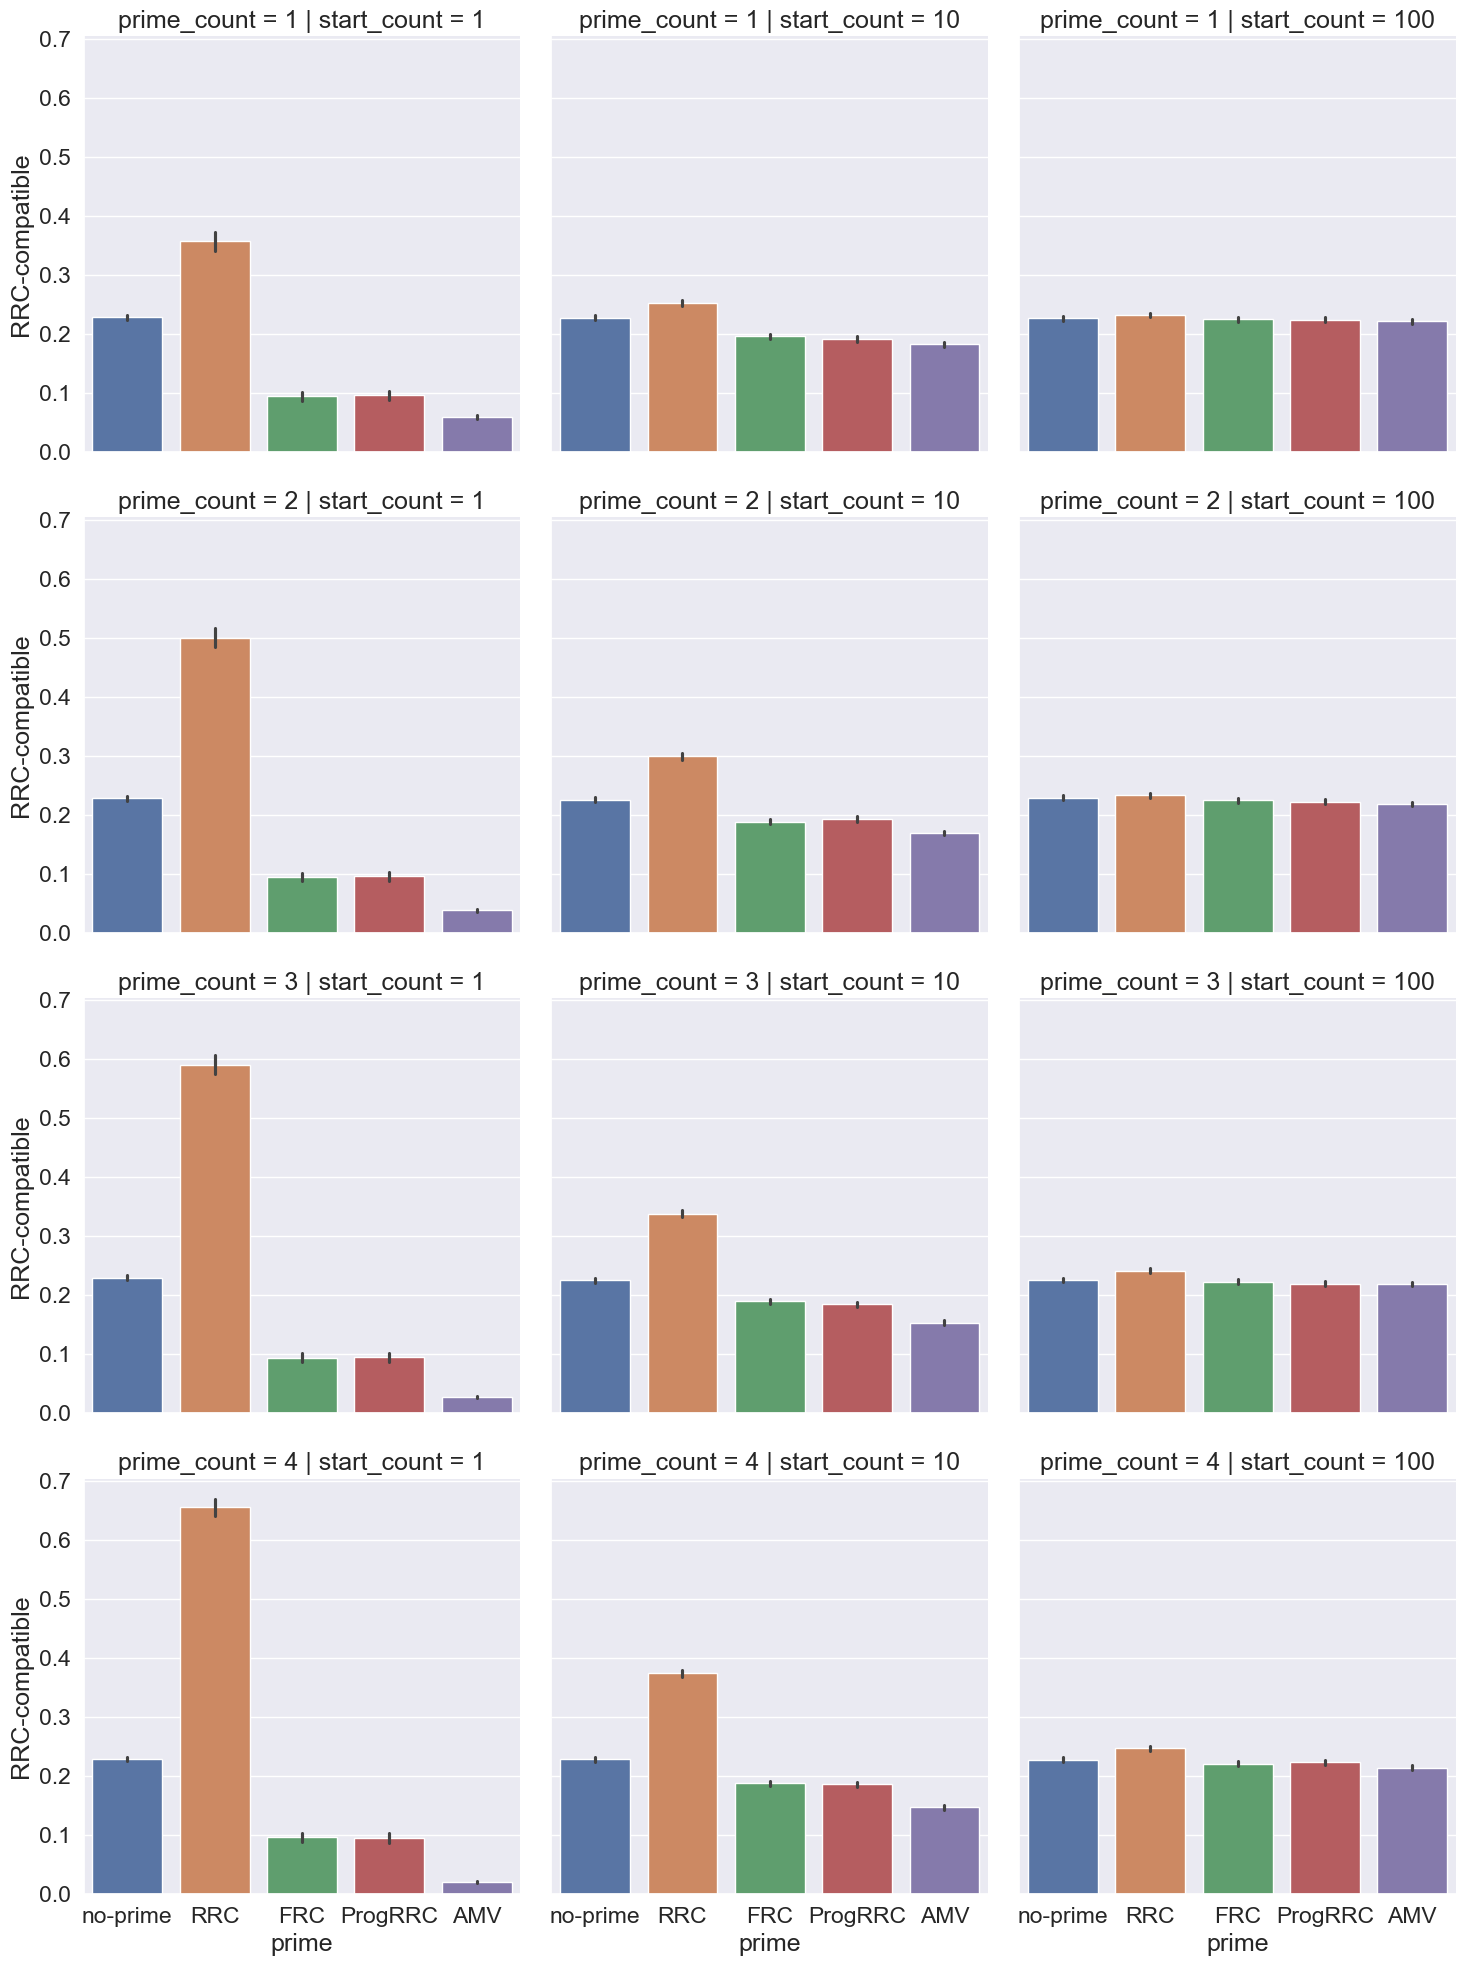

In [5]:
sns.set(font_scale=1.5)

sns.catplot(data=pred_df,
            x="prime",
            y="RRC-compatible",
            hue = "prime",
            kind="bar", 
            row="prime_count",
            col="start_count")